In [41]:
import os
import numpy as np
import random
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import monai
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd, Spacingd, Resized, RandFlipd,
    RandRotate90d, RandShiftIntensityd, ToTensord, EnsureTyped
)
from monai.data import Dataset, CacheDataset, decollate_batch
from monai.networks.nets import UNet, SwinUNETR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference

import SimpleITK as sitk  # used in your notebook earlier
import joblib
import time

In [42]:
# ----------------------
# CONFIG (edit paths/sizes/batches for your environment)
# ----------------------
CONFIG = {
    "paths": {
        "task1_unlabeled_dir": "D:\\dharaneesh\\csv_lists\\task1_unlabeled.csv",   # directory or csv describing unlabeled T1 volumes
        "task1_train_csv": "D:\\dharaneesh\\csv_lists\\task1_train_fixed.csv",
        "task1_val_csv":   "D:\\dharaneesh\\csv_lists\\task1_val_fixed.csv",
        "task2_train_csv": "D:\\dharaneesh\\csv_lists\\task2_train_fixed.csv",
        "task2_val_csv":   "D:\\dharaneesh\\csv_lists\\task2_val_fixed.csv",
        "save_dir": "./models"
    },
    "img_size": (128, 128, 128),   # resize/resample target shape (z,y,x) or (d,h,w)
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 2,
    "ssl_epochs": 30,
    "sup_epochs": 40,
    "task2_epochs": 30,
    "lr": 1e-4,
    "seed": 42
}

os.makedirs(CONFIG["paths"]["save_dir"], exist_ok=True)

In [43]:
# ----------------------
# seed
# ----------------------
def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(CONFIG["seed"])

In [44]:
import pandas as pd
def csv_to_monai_list(csv_path):
    df = pd.read_csv(csv_path, header=None)
    pairs = []
    for _, row in df.iterrows():
        img, lbl = str(row[0]), str(row[1])
        pairs.append({"image": img, "label": lbl})
    return pairs

In [45]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd,
    Resized, RandFlipd, RandRotate90d, RandShiftIntensityd,
    ToTensord, Lambdad, CastToTyped
)
import torch

# ✅ define this once so it's picklable
def cast_to_int32(x):
    return x.astype("int32")


def get_transforms(img_size, mode="train"):
    if mode == "train":
        tr = Compose([
            LoadImaged(keys=["image", "label"]),   # 👈 removed reader
            EnsureChannelFirstd(keys=["image", "label"]),
            ScaleIntensityd(keys=["image"]),
            Lambdad(keys=["label"], func=cast_to_int32),
            Resized(keys=["image","label"], spatial_size=img_size, mode=("trilinear","nearest")),
            RandFlipd(keys=["image","label"], prob=0.5, spatial_axis=0),
            RandRotate90d(keys=["image","label"], prob=0.5, max_k=3),
            RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
            ToTensord(keys=["image","label"])
        ])
    else:
        tr = Compose([
            LoadImaged(keys=["image","label"]),   # 👈 removed reader
            EnsureChannelFirstd(keys=["image","label"]),
            ScaleIntensityd(keys=["image"]),
            Lambdad(keys=["label"], func=cast_to_int32),
            Resized(keys=["image","label"], spatial_size=img_size, mode=("trilinear","nearest")),
            ToTensord(keys=["image","label"])
        ])
    return tr


def get_ssl_transforms(img_size, train=True):
    if train:
        tr = Compose([
            LoadImaged(keys=["image"]),   # 👈 removed reader
            EnsureChannelFirstd(keys=["image"]),
            ScaleIntensityd(keys=["image"]),
            Resized(keys=["image"], spatial_size=img_size),
            RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
            RandRotate90d(keys=["image"], prob=0.5, max_k=3),
            RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
            ToTensord(keys=["image"])
        ])
    else:
        tr = Compose([
            LoadImaged(keys=["image"]),   # 👈 removed reader
            EnsureChannelFirstd(keys=["image"]),
            ScaleIntensityd(keys=["image"]),
            Resized(keys=["image"], spatial_size=img_size),
            ToTensord(keys=["image"])
        ])
    return tr



In [46]:
# ----------------------
# Data loaders
# ----------------------
def make_loader_from_pairs(pairs, transforms, batch_size=CONFIG["batch_size"], shuffle=True, cache=False):
    if cache:
        ds = CacheDataset(data=pairs, transform=transforms, cache_rate=1.0)
    else:
        ds = Dataset(data=pairs, transform=transforms)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True)
    return dl

In [47]:
def random_mask_volume(x, mask_ratio=0.25):
    # x: tensor (B,C,D,H,W)
    B,C,D,H,W = x.shape
    total = D*H*W
    num_mask = int(total * mask_ratio)
    x_masked = x.clone()
    masks = torch.ones_like(x)
    for b in range(B):
        idx = torch.randperm(total)[:num_mask]
        flat = x_masked[b].view(-1)
        flat[idx] = 0.0
        masks[b].view(-1)[idx] = 0.0
    return x_masked, masks

In [48]:
import pandas as pd
from monai.data import Dataset, DataLoader

# pick one file from csv
df = pd.read_csv(r"D:\dharaneesh\csv_lists\task1_train.csv")
sample = [{"image": df.iloc[0,0], "label": df.iloc[0,1]}]

# supervised test
ds = Dataset(data=sample, transform=get_transforms(CONFIG["img_size"], mode="train"))
dl = DataLoader(ds, batch_size=1)

batch = next(iter(dl))
print("Supervised shapes:", batch["image"].shape, batch["label"].shape, batch["label"].dtype)

# ssl test
df_ssl = pd.read_csv(r"D:\dharaneesh\csv_lists\task1_unlabeled.csv")
sample_ssl = [{"image": df_ssl.iloc[0,0]}]

ds_ssl = Dataset(data=sample_ssl, transform=get_ssl_transforms(CONFIG["img_size"], train=True))
dl_ssl = DataLoader(ds_ssl, batch_size=1)

batch_ssl = next(iter(dl_ssl))
print("SSL shapes:", batch_ssl["image"].shape)


Supervised shapes: torch.Size([1, 1, 128, 128, 128]) torch.Size([1, 1, 128, 128, 128]) torch.float32
SSL shapes: torch.Size([1, 1, 128, 128, 128])


In [49]:
def ssl_pretrain_autoencoder(unlabeled_pairs, img_size=CONFIG["img_size"], epochs=10, lr=1e-4, device=CONFIG["device"], save_path=None):
    print("Start SSL pretraining (autoencoder reconstruction)...")
    tr = get_ssl_transforms(img_size, train=True)
    dl = make_loader_from_pairs(unlabeled_pairs, tr, batch_size=CONFIG["batch_size"], shuffle=True, cache=False)
    # Use UNet as autoencoder (in_channels=1, out_channels=1)
    ae = UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=1,
        channels=(16,32,64,128,256),
        strides=(2,2,2,2),
        num_res_units=2
    ).to(device)

    opt = torch.optim. Adam(ae.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {"loss": []}
    for epoch in range(epochs):
        ae.train()
        epoch_loss = 0.0
        steps = 0
        t0 = time.time()
        for batch in dl:
            imgs = batch["image"].to(device).float()
            imgs_masked, mask = random_mask_volume(imgs, mask_ratio=0.3)
            preds = ae(imgs_masked)
            loss = criterion(preds * (1-mask), imgs * (1-mask))  # reconstruct masked region (alternative: full mse)
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item(); steps += 1
        avg = epoch_loss/steps
        history["loss"].append(avg)
        print(f"SSL Epoch {epoch+1}/{epochs}  loss={avg:.6f}  time={(time.time()-t0):.1f}s")
    if save_path:
        torch.save(ae.state_dict(), save_path)
        print("Saved SSL model to", save_path)
    return ae, history

In [50]:
def build_segmentation_unet(img_size=CONFIG["img_size"], in_channels=1, out_channels=1, device=CONFIG["device"]):
    model = UNet(
        spatial_dims=3,
        in_channels=in_channels,
        out_channels=out_channels,
        channels=(16,32,64,128,256),
        strides=(2,2,2,2),
        num_res_units=2
    ).to(device)
    return model

In [51]:
def load_encoder_weights_into_unet(ae, unet_model):
    # ae and unet_model are both UNet instances with similar architecture in this script,
    # so a straightforward load_state_dict will work. If encoder architectures differ,
    # a custom mapping is required.
    try:
        unet_model.load_state_dict(ae.state_dict(), strict=False)
        print("Loaded weights from AE into segmentation UNet (non-strict).")
    except Exception as e:
        print("Non-strict load failed; try manual mapping. Error:", e)

In [52]:
# ----------------------
# Training loop (supervised)
# ----------------------
def train_supervised(model, train_loader, val_loader, epochs=20, lr=1e-4, device=CONFIG["device"], save_path=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = DiceLoss(sigmoid=True)  # if labels are 0/1 float; adjust if using BCE+Dice
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    post_pred = AsDiscrete(threshold=0.5)
    post_label = AsDiscrete(threshold=0.5)

    train_losses, val_losses, val_dices = [], [], []

    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        train_loss_epoch = 0.0; train_steps = 0
        for batch in train_loader:
            imgs, labels = batch["image"].to(device).float(), batch["label"].to(device).float()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss_epoch += loss.item(); train_steps += 1
        avg_train_loss = train_loss_epoch / train_steps
        train_losses.append(avg_train_loss)

        # validation
        model.eval()
        val_loss_epoch = 0.0; val_steps = 0
        dice_metric.reset()
        with torch.no_grad():
            for batch in val_loader:
                imgs, labels = batch["image"].to(device).float(), batch["label"].to(device).float()
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss_epoch += loss.item(); val_steps += 1

                preds = post_pred(outputs)
                labs = post_label(labels)
                dice_metric(y_pred=preds, y=labs)
            mean_dice = dice_metric.aggregate().item()
            dice_metric.reset()

        avg_val_loss = val_loss_epoch / val_steps
        val_losses.append(avg_val_loss)
        val_dices.append(mean_dice)
        print(f"[Epoch {epoch+1}/{epochs}] train_loss={avg_train_loss:.4f} val_loss={avg_val_loss:.4f} val_dice={mean_dice:.4f} time={(time.time()-t0):.1f}s")

        # optionally save best
        if save_path:
            torch.save(model.state_dict(), save_path)

    return model, {"train_losses": train_losses, "val_losses": val_losses, "val_dices": val_dices}

In [53]:
# ----------------------
# Extended Evaluation: Dice, IoU, Hausdorff, Precision, Recall, Specificity, ASD, VS
# ----------------------
import numpy as np
import torch
from monai.metrics import HausdorffDistanceMetric, SurfaceDistanceMetric
from monai.transforms import AsDiscrete

def evaluate_full(model, val_loader, device=CONFIG["device"]):
    model.eval()
    post_pred = AsDiscrete(threshold=0.5)
    post_label = AsDiscrete(threshold=0.5)

    dice_list, iou_list, haus_list = [], [], []
    precision_list, recall_list, specificity_list, vs_list, asd_list = [], [], [], [], []

    haus_metric = HausdorffDistanceMetric(include_background=False, percentile=95)
    asd_metric = SurfaceDistanceMetric(include_background=False, symmetric=True)

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(device).float()
            labels = batch["label"].to(device).float()
            outputs = model(imgs)
            preds = post_pred(outputs)
            labs = post_label(labels)

            smooth = 1e-5
            preds_n = preds.cpu().numpy().astype(np.uint8)
            labs_n = labs.cpu().numpy().astype(np.uint8)

            for p, l in zip(preds_n, labs_n):
                p = p[0]; l = l[0]  # channel dim
                tp = np.logical_and(p == 1, l == 1).sum()
                fp = np.logical_and(p == 1, l == 0).sum()
                fn = np.logical_and(p == 0, l == 1).sum()
                tn = np.logical_and(p == 0, l == 0).sum()

                # Metrics
                dice = (2 * tp) / (2 * tp + fp + fn + smooth)
                iou = tp / (tp + fp + fn + smooth)
                precision = tp / (tp + fp + smooth)
                recall = tp / (tp + fn + smooth)
                specificity = tn / (tn + fp + smooth)
                vs = 1 - abs(p.sum() - l.sum()) / (p.sum() + l.sum() + smooth)

                dice_list.append(dice)
                iou_list.append(iou)
                precision_list.append(precision)
                recall_list.append(recall)
                specificity_list.append(specificity)
                vs_list.append(vs)

            # Tensor-based metrics
            try:
                hd = haus_metric(preds.cpu(), labs.cpu())
                asd = asd_metric(preds.cpu(), labs.cpu())
                haus_list.append(float(hd.item()))
                asd_list.append(float(asd.item()))
            except Exception:
                haus_list.append(np.nan)
                asd_list.append(np.nan)

    return {
        "dice_mean": float(np.nanmean(dice_list)),
        "iou_mean": float(np.nanmean(iou_list)),
        "hausdorff_mean": float(np.nanmean(haus_list)),
        "asd_mean": float(np.nanmean(asd_list)),
        "precision_mean": float(np.nanmean(precision_list)),
        "recall_mean": float(np.nanmean(recall_list)),
        "specificity_mean": float(np.nanmean(specificity_list)),
        "volume_similarity_mean": float(np.nanmean(vs_list))
    }


In [54]:
# ----------------------
# Visualization helper
# ----------------------
def visualize_prediction(model, data_loader, device=CONFIG["device"], slice_axis=2):
    model.eval()
    with torch.no_grad():
        batch = next(iter(data_loader))
        imgs = batch["image"].to(device).float()
        labels = batch["label"].to(device).float()
        outputs = model(imgs)
        preds = (torch.sigmoid(outputs) > 0.5).float()

        # show 1st volume central slice
        vol = imgs[0,0].cpu().numpy()
        lab = labels[0,0].cpu().numpy()
        pr = preds[0,0].cpu().numpy()

        # choose middle slice along last axis
        idx = vol.shape[slice_axis] // 2
        if slice_axis == 0:
            im = vol[idx,:,:]; la = lab[idx,:,:]; prd = pr[idx,:,:]
        elif slice_axis == 1:
            im = vol[:,idx,:]; la = lab[:,idx,:]; prd = pr[:,idx,:]
        else:
            im = vol[:,:,idx]; la = lab[:,:,idx]; prd = pr[:,:,idx]

        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(im, cmap="gray"); plt.title("Input")
        plt.subplot(1,3,2); plt.imshow(la, cmap="gray"); plt.title("Label")
        plt.subplot(1,3,3); plt.imshow(prd, cmap="gray"); plt.title("Pred")
        plt.show()

In [55]:
# ----------------------
# TRAINING EXECUTION PIPELINE (Task 1 and Task 2)
# ----------------------
def run_task1_and_task2():
    device = CONFIG["device"]

    # ===== Task 1: SSL pretrain on unlabeled T1 =====
    # Provide unlabeled_pairs: a list of dicts {"image":path}
    # If you have a csv for unlabeled images, load it accordingly
    # Example: unlabeled_csv has one column image_path
    unlabeled_pairs = []
    ul_dir = CONFIG["paths"]["task1_unlabeled_dir"]
    if os.path.isdir(ul_dir):
        # auto-collect .mha/.nii* images if folder provided
        for root, _, files in os.walk(ul_dir):
            for f in files:
                if f.lower().endswith((".mha", ".mhd", ".nii", ".nii.gz")):
                    unlabeled_pairs.append({"image": os.path.join(root, f)})
    else:
        # fallback: if path is csv, parse it
        if os.path.isfile(CONFIG["paths"]["task1_unlabeled_dir"]):
            df = pd.read_csv(CONFIG["paths"]["task1_unlabeled_dir"], header=None)
            for _, row in df.iterrows():
                unlabeled_pairs.append({"image": str(row[0])})

    print(f"Found {len(unlabeled_pairs)} unlabeled volumes for SSL.")

    ssl_model_path = os.path.join(CONFIG["paths"]["save_dir"], "ssl_ae.pth")
    if len(unlabeled_pairs) > 0:
        ae, ssl_hist = ssl_pretrain_autoencoder(unlabeled_pairs, img_size=CONFIG["img_size"], epochs=CONFIG["ssl_epochs"], lr=CONFIG["lr"], device=device, save_path=ssl_model_path)
    else:
        ae = None
        print("No unlabeled data found. Skipping SSL pretraining.")

    # ===== Task 1 Supervised: Train segmentation on annotated T1 =====
    dl_train = make_loader_from_pairs(csv_to_monai_list(CONFIG["paths"]["task1_train_csv"]), get_transforms(CONFIG["img_size"], "train"), batch_size=CONFIG["batch_size"], shuffle=True)
    dl_val   = make_loader_from_pairs(csv_to_monai_list(CONFIG["paths"]["task1_val_csv"]), get_transforms(CONFIG["img_size"], "val"), batch_size=1, shuffle=False)

    seg_model = build_segmentation_unet(img_size=CONFIG["img_size"], in_channels=1, out_channels=1, device=device)
    if ae is not None:
        load_encoder_weights_into_unet(ae, seg_model)

    seg_save_path = os.path.join(CONFIG["paths"]["save_dir"], "task1_seg.pth")
    seg_model, sup_history = train_supervised(seg_model, dl_train, dl_val, epochs=CONFIG["sup_epochs"], lr=CONFIG["lr"], device=device, save_path=seg_save_path)

    # Plot training curves
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(sup_history["train_losses"], label="train_loss")
    plt.plot(sup_history["val_losses"], label="val_loss")
    plt.legend(); plt.title("Loss")
    plt.subplot(1,2,2)
    plt.plot(sup_history["val_dices"], label="val_dice"); plt.legend(); plt.title("Val Dice")
    plt.show()

    # Evaluate thoroughly
    metrics_task1 = evaluate_full(seg_model, dl_val, device=device)
    print("Task1 eval:", metrics_task1)
    visualize_prediction(seg_model, dl_val, device=device)

    # ===== Task 2: Transfer Learning to T2 (few-shot) =====
    # load T2 train/val csvs
    dl2_train = make_loader_from_pairs(csv_to_monai_list(CONFIG["paths"]["task2_train_csv"]), get_transforms(CONFIG["img_size"], "train"), batch_size=CONFIG["batch_size"], shuffle=True)
    dl2_val   = make_loader_from_pairs(csv_to_monai_list(CONFIG["paths"]["task2_val_csv"]), get_transforms(CONFIG["img_size"], "val"), batch_size=1, shuffle=False)

    # Build new segmentation model for Task2 and initialize from task1 seg_model
    task2_model = build_segmentation_unet(img_size=CONFIG["img_size"], in_channels=1, out_channels=1, device=device)
    # load segmentation weights (encoder + decoder) as starting point if available
    if os.path.exists(seg_save_path):
        task2_model.load_state_dict(torch.load(seg_save_path), strict=False)
        print("Initialized Task2 model from Task1 weights (partial load).")

    # Optionally freeze encoder layers (do this for few-shot)
    freeze_encoder = True
    if freeze_encoder:
        # naive approach: freeze first half of parameters
        n_params = len(list(task2_model.parameters()))
        for i, p in enumerate(task2_model.parameters()):
            if i < n_params // 2:
                p.requires_grad = False

    task2_save = os.path.join(CONFIG["paths"]["save_dir"], "task2_finetuned.pth")
    task2_model, task2_hist = train_supervised(task2_model, dl2_train, dl2_val, epochs=CONFIG["task2_epochs"], lr=CONFIG["lr"], device=device, save_path=task2_save)

    # Evaluate Task2
    metrics_task2 = evaluate_full(task2_model, dl2_val, device=device)
    print("Task2 eval:", metrics_task2)
    visualize_prediction(task2_model, dl2_val, device=device)

    # Return models and metrics
    return {
        "ssl_model": ae,
        "task1_model": seg_model,
        "task2_model": task2_model,
        "metrics_task1": metrics_task1,
        "metrics_task2": metrics_task2,
        "hist_task1": sup_history,
        "hist_task2": task2_hist
    }


Found 367 unlabeled volumes for SSL.
Start SSL pretraining (autoencoder reconstruction)...
SSL Epoch 1/30  loss=0.050008  time=94.9s
SSL Epoch 2/30  loss=0.016887  time=89.7s
SSL Epoch 3/30  loss=0.006971  time=90.4s
SSL Epoch 4/30  loss=0.003643  time=88.8s
SSL Epoch 5/30  loss=0.002975  time=89.1s
SSL Epoch 6/30  loss=0.002583  time=88.8s
SSL Epoch 7/30  loss=0.002371  time=88.6s
SSL Epoch 8/30  loss=0.002099  time=88.8s
SSL Epoch 9/30  loss=0.001905  time=88.8s
SSL Epoch 10/30  loss=0.001653  time=88.5s
SSL Epoch 11/30  loss=0.001681  time=88.6s
SSL Epoch 12/30  loss=0.001591  time=89.9s
SSL Epoch 13/30  loss=0.001488  time=89.3s
SSL Epoch 14/30  loss=0.001372  time=88.2s
SSL Epoch 15/30  loss=0.001260  time=91.8s
SSL Epoch 16/30  loss=0.001267  time=97.5s
SSL Epoch 17/30  loss=0.001154  time=94.9s
SSL Epoch 18/30  loss=0.001088  time=94.3s
SSL Epoch 19/30  loss=0.001004  time=94.5s
SSL Epoch 20/30  loss=0.000947  time=97.3s
SSL Epoch 21/30  loss=0.000841  time=97.4s
SSL Epoch 22/30

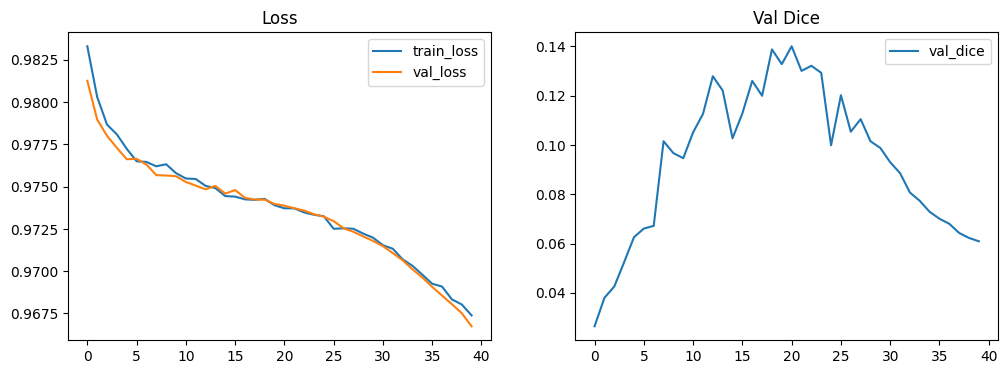

monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.


Task1 eval: {'dice_mean': 0.06093156555614872, 'iou_mean': 0.03157943412913212, 'hausdorff_mean': 37.015444705360814, 'asd_mean': 22.615449704621966, 'precision_mean': 0.031582520269068916, 'recall_mean': 0.9991679197889836, 'specificity_mean': 0.8915858150817078, 'volume_similarity_mean': 0.06102488423678682}


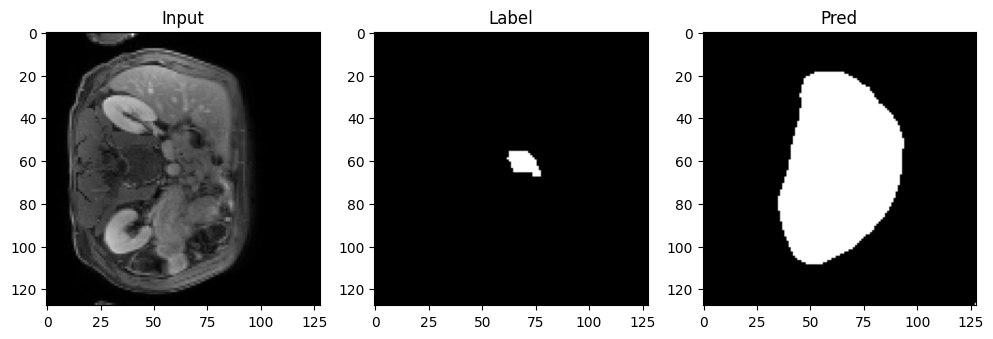

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Initialized Task2 model from Task1 weights (partial load).
[Epoch 1/30] train_loss=0.9766 val_loss=0.9787 val_dice=0.0382 time=43.2s
[Epoch 2/30] train_loss=0.9762 val_loss=0.9789 val_dice=0.0382 time=39.9s
[Epoch 3/30] train_loss=0.9760 val_loss=0.9786 val_dice=0.0380 time=37.2s
[Epoch 4/30] train_loss=0.9759 val_loss=0.9784 val_dice=0.0383 time=38.2s
[Epoch 5/30] train_loss=0.9757 val_loss=0.9781 val_dice=0.0385 time=38.4s
[Epoch 6/30] train_loss=0.9755 val_loss=0.9780 val_dice=0.0378 time=38.6s
[Epoch 7/30] train_loss=0.9753 val_loss=0.9779 val_dice=0.0380 time=37.6s
[Epoch 8/30] train_loss=0.9752 val_loss=0.9777 val_dice=0.0380 time=38.4s
[Epoch 9/30] train_loss=0.9750 val_loss=0.9775 val_dice=0.0373 time=36.4s
[Epoch 10/30] train_loss=0.9748 val_loss=0.9774 val_dice=0.0375 time=37.6s
[Epoch 11/30] train_loss=0.9746 val_loss=0.9772 val_dice=0.0369 time=36.9s
[Epoch 12/30] train_loss=0.9745 val_loss=0.9770 val_dice=0.0358 time=37.6s
[Epoch 13/30] train_loss=0.9743 val_loss=0.9769 va

monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.


Task2 eval: {'dice_mean': 0.03635075954479271, 'iou_mean': 0.018566543227593692, 'hausdorff_mean': 36.82928676605225, 'asd_mean': 25.118801879882813, 'precision_mean': 0.018567661942147817, 'recall_mean': 0.991828663122306, 'specificity_mean': 0.8836725544419437, 'volume_similarity_mean': 0.036547997458858714}


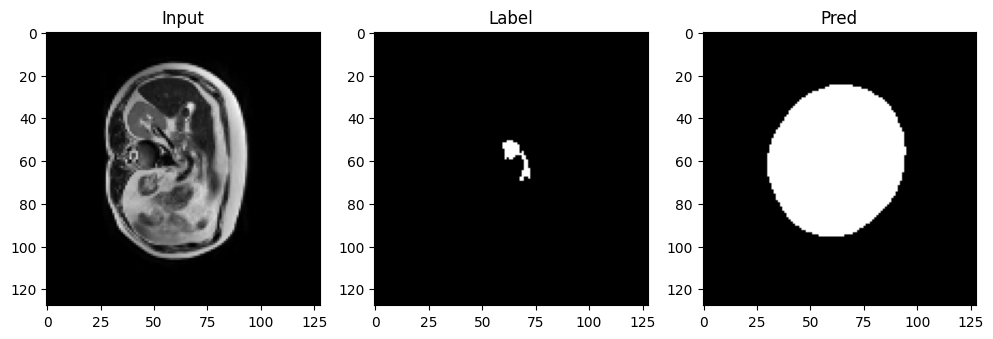

Task 1 Results (T1 MRI segmentation): {'dice_mean': 0.06093156555614872, 'iou_mean': 0.03157943412913212, 'hausdorff_mean': 37.015444705360814, 'asd_mean': 22.615449704621966, 'precision_mean': 0.031582520269068916, 'recall_mean': 0.9991679197889836, 'specificity_mean': 0.8915858150817078, 'volume_similarity_mean': 0.06102488423678682}
Task 2 Results (T2 MRI segmentation): {'dice_mean': 0.03635075954479271, 'iou_mean': 0.018566543227593692, 'hausdorff_mean': 36.82928676605225, 'asd_mean': 25.118801879882813, 'precision_mean': 0.018567661942147817, 'recall_mean': 0.991828663122306, 'specificity_mean': 0.8836725544419437, 'volume_similarity_mean': 0.036547997458858714}


In [56]:
results = run_task1_and_task2()

# Print evaluation metrics
print("Task 1 Results (T1 MRI segmentation):", results["metrics_task1"])
print("Task 2 Results (T2 MRI segmentation):", results["metrics_task2"])

In [57]:
print("Task 1 Evaluation:", results["metrics_task1"])
print("Task 2 Evaluation:", results["metrics_task2"])



Task 1 Evaluation: {'dice_mean': 0.06093156555614872, 'iou_mean': 0.03157943412913212, 'hausdorff_mean': 37.015444705360814, 'asd_mean': 22.615449704621966, 'precision_mean': 0.031582520269068916, 'recall_mean': 0.9991679197889836, 'specificity_mean': 0.8915858150817078, 'volume_similarity_mean': 0.06102488423678682}
Task 2 Evaluation: {'dice_mean': 0.03635075954479271, 'iou_mean': 0.018566543227593692, 'hausdorff_mean': 36.82928676605225, 'asd_mean': 25.118801879882813, 'precision_mean': 0.018567661942147817, 'recall_mean': 0.991828663122306, 'specificity_mean': 0.8836725544419437, 'volume_similarity_mean': 0.036547997458858714}
